# Modelling the magnetization of oceanic lithosphere

In this tutorial we will go through the steps to forward model the magnetic field due to oceanic lithosphere, assuming that the main source 

In [2]:
# add relative path the remit folder
import sys
sys.path.append('../')

# import basic dependencies
import matplotlib.pyplot as plt
import numpy as np
import pygmt

from remit.data.models import load_vis_model, load_ocean_age_model

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load a model of the seafloor age

Our model of the seafloor magnetization will depend on a model for how the seafloor formed since the breakup of Pangea. We will model the magnetization vector at each grid node based on the when and where each node formed in geological time. To do this, we will load a model defined using plate tectonic reconstructions, such that for each grid nodes we have values for:
- age (in Myr)
- paleolatitude (latitude of the grid node at the time it formed)
- declination (telling us how the seafloor at the grid node has rotated relative to north since it formed)

These grids must be precomputed in a self-consistent manner. Different reconstruction models (in terms of the seafloor spreading history and the Apparent Polar Wander Path, APWP) would give slightly different estimates of thes three grids. 

The grids for various Earthbyte reconstructions are contained within the code 'data' folders, and can be loaded using the 'load_ocean_age_model'. By default we use a model with seafloor age after Seton et al (2020) and the APWP of Merdith et al (2020).

In [17]:
ocean = load_ocean_age_model()

ocean


lats = -90.0000 - 90.0000 length = 1801
lons = 0.0000 - 360.0000 length = 3601
age_min = 0.01, age_max = 338.68

Lets plot the three grids (Age, paleolatitude and declination)

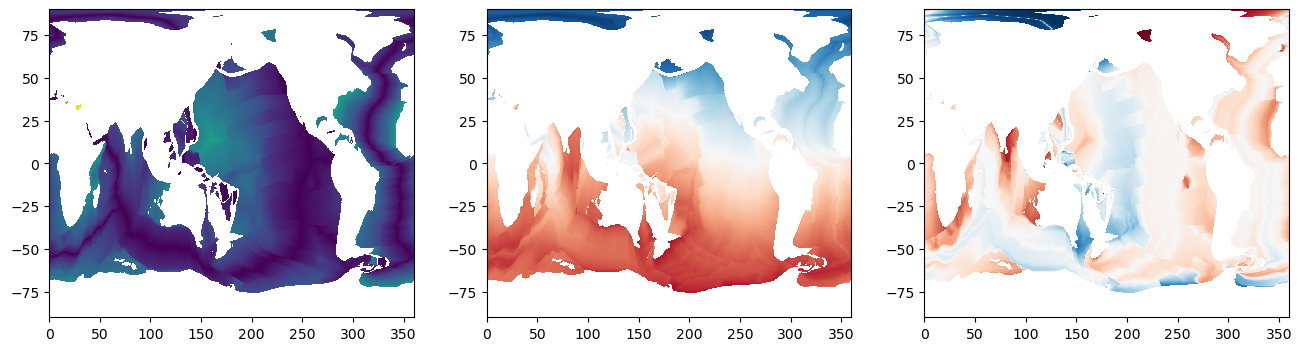

In [31]:
fig,ax = plt.subplots(ncols=3, figsize=(16,4))
ax[0].pcolormesh(ocean.lon, ocean.lat, ocean.age)
#ax[0].colorbar()
ax[1].pcolormesh(ocean.lon, ocean.lat, ocean.paleolatitude, vmin=-90, vmax=90, cmap='RdBu')
ax[2].pcolormesh(ocean.lon, ocean.lat, ocean.declination, vmin=-90, vmax=90, cmap='RdBu')
plt.show()

## Create a generic model for magnetization as a function of seafloor age

In this step we go from a map of seafloor age to a model for the magnetization across this seafloor. To do this, we first generate an estimate how magnetization would vary as a function of age, then apply this to the global map with age defined at each grid node.

For the first step, we use the class 'SeafloorAgeProfile' to generate the generic model of magnetization as a function of seafloor age.

A basic assumption we can make for oceanic lithosphere is that a dominant control on the magnetization is the remanent magnetization acquired at the time the seafloor formed. This remanent magnetization alternates between normal and reverse polarity according to flips in the polarity of the geomagnetic field over geological time. These flips are fairly well studied so that we have an existing timescale that maps age (in Millions of years, Myr) to the polarity changes - the Geomagnetic Polarity Time Scale (GPTS). A default GPTS is included within the modelling code, thought this can be changed if desired.



Text(0, 0.5, 'VIM')

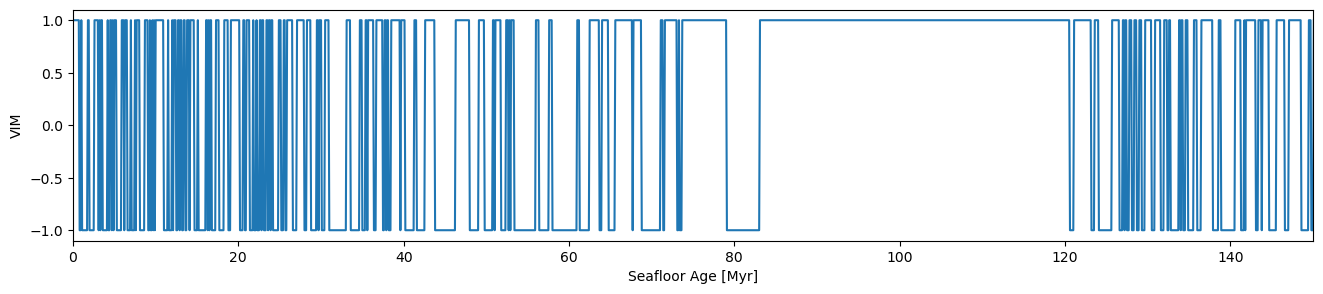

In [48]:
from remit.earthvim import SeafloorAgeProfile

rvim_profile = SeafloorAgeProfile.layer1d(Mtrm=1, Mcrm=0, P=0, MagMax=1, layer_thickness=1)

fig,ax = plt.subplots(figsize=(16,3))
ax.plot(rvim_profile.age, rvim_profile.RVIM)
ax.set_xlim(0,150)
ax.set_xlabel('Seafloor Age [Myr]')
ax.set_ylabel('VIM')


Now, let's try some more realistic parameters.

- layer_thickness (defined in m) set to 1000 m
- MagMax sets the maximum magnetization at zero-age
- P is a partition coefficient which controls what proportion of the intitial magnetization survives after decay due to low temperature alteration
- lmbda controls the timescale of the magnetization decay


Text(0, 0.5, 'VIM')

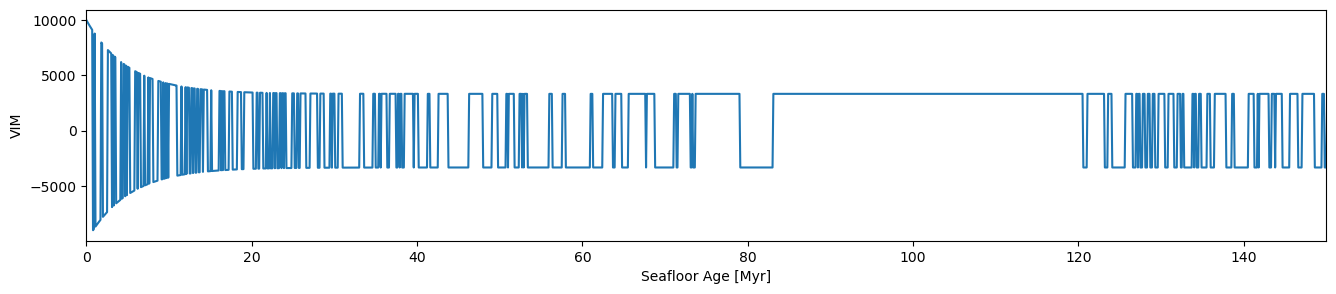

In [50]:
rvim_profile = SeafloorAgeProfile.layer1d(Mtrm=1, Mcrm=0, P=2, MagMax=10, layer_thickness=1000)

fig,ax = plt.subplots(figsize=(16,3))
ax.plot(rvim_profile.age, rvim_profile.RVIM)
ax.set_xlim(0,150)
ax.set_xlabel('Seafloor Age [Myr]')
ax.set_ylabel('VIM')


For satellite data where the long-wavelength component of the anomalies is important, we generally use a model where the depth-dependence of magnetization is taken into account.



(0.0, 150.0)

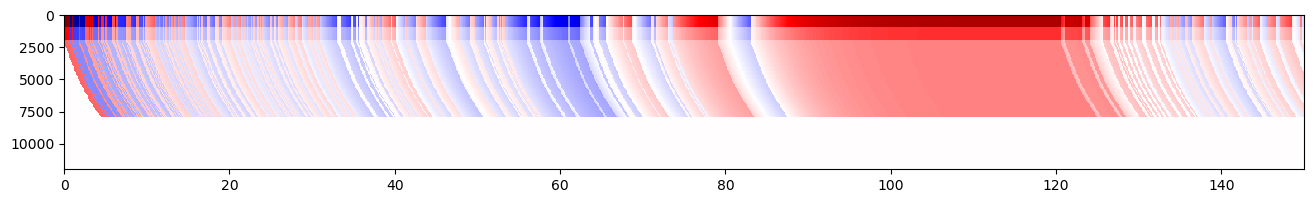

In [53]:
rvim_profile = SeafloorAgeProfile.layer2d(layer_boundary_depths=[0,1000,2000,8000],
                                          layer_weights=[1,0.5,0.3])

fig,ax = plt.subplots(figsize=(16,2))
ax.pcolormesh(rvim_profile.age, rvim_profile.depth, rvim_profile.RM,
              cmap='seismic', vmin=-1000, vmax=1000)
ax.set_ylim(12000,0)
ax.set_xlim(0,150)


## Generate global magnetization maps

Whichever generic profile of remanent VIM we generate from the above options, we can combine this with the maps of seafloor age, paleolatitude and declination to get magnetization vectors for the oceans. 

Once a 'SeafloorGrid' object has been created, the method 'vim' will generate a new magnetization model. The result depends on the seafloor and and vector directions defined at each grid point, combined with the generic age versus magnetization magnitude profile computed above. Another assumption here is that the remanent magnetization results from a geocentric axial dipole in existence throughout the time that the seafloor was being generated.


(<Figure size 1500x400 with 6 Axes>, <Axes: title={'center': 'Mphi'}>)

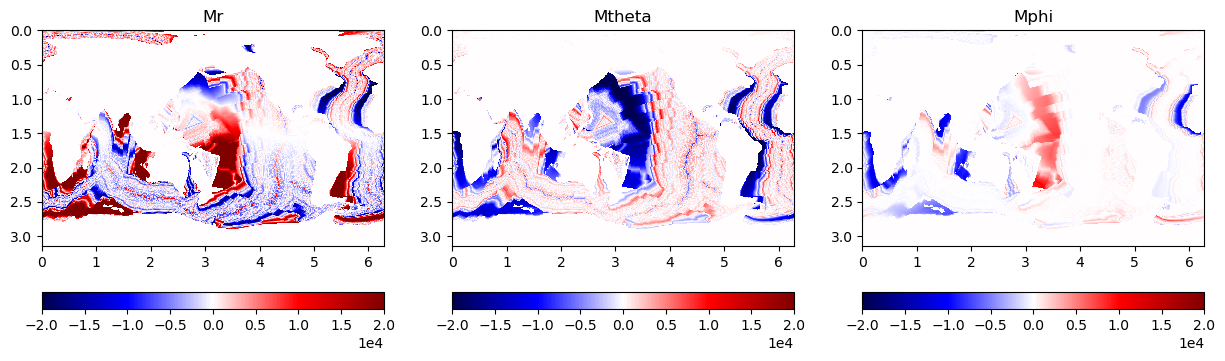

In [15]:
ocean_vim = ocean.vim(rvim_profile)

ocean_vim.plot()


## Combine ocean remanence with induced magnetization

To generate a magnetization model for the whole Earth, we need to combine the ocean remanence model with the model for the induced magnetization (assumed to dominate in the continents). Such a model was introduced on the first tutorial. 

An additional factor here is that we need the two models to have consistent grid coordinates (which the source grids may not). In this example, we load the vis in such a way as to resample the VIS grid to match the ocean magnetization model we already loaded, this ensuring they are consistent. 


In [55]:
vis = load_vis_model(name='Hemant2005+slabs',
                     match=(ocean.lon, ocean.lat, ocean.age))



/Users/simon/GIT/vh0/remit/utils/grid.py:220: FutureWarning: It is recommended to use 'rio.write_crs()' instead. 'rio.set_crs()' will likelybe removed in a future release.
  da.rio.set_crs("epsg:4326")


Now, we can create a global VIM model by combination of the ocean remanence and the induced magnetization arising from the magnetic susceptibility. (Note that the induced magnetization depends on a model for the present-day field, unlike the remanent VIM for which a GAD was assumed)

(<Figure size 1500x400 with 6 Axes>, <Axes: title={'center': 'Mphi'}>)

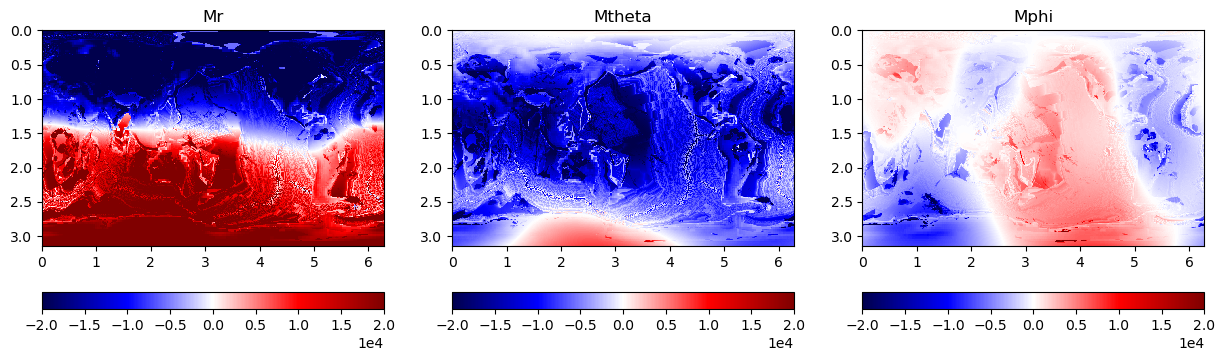

In [7]:
from remit.data.models import create_vim

totalvim = create_vim(ocean, vis)#, **layer_params)

totalvim.plot()

Now that we have a global VIM model, we can use this to generate spherical harmonic coefficients for the lithospheric field that can be compared to satellite observations (as detailed in previous tutorials)

In [69]:
from remit.utils.grid import coeffs2map

lmax = 140
vsh, coeffs = totalvim.transform(lmax=lmax)

model_rad = coeffs2map(coeffs, altitude=10000, lmax=lmax, lmin=16)

This time we'll make a pygmt plot. As before we focus on the radial component.

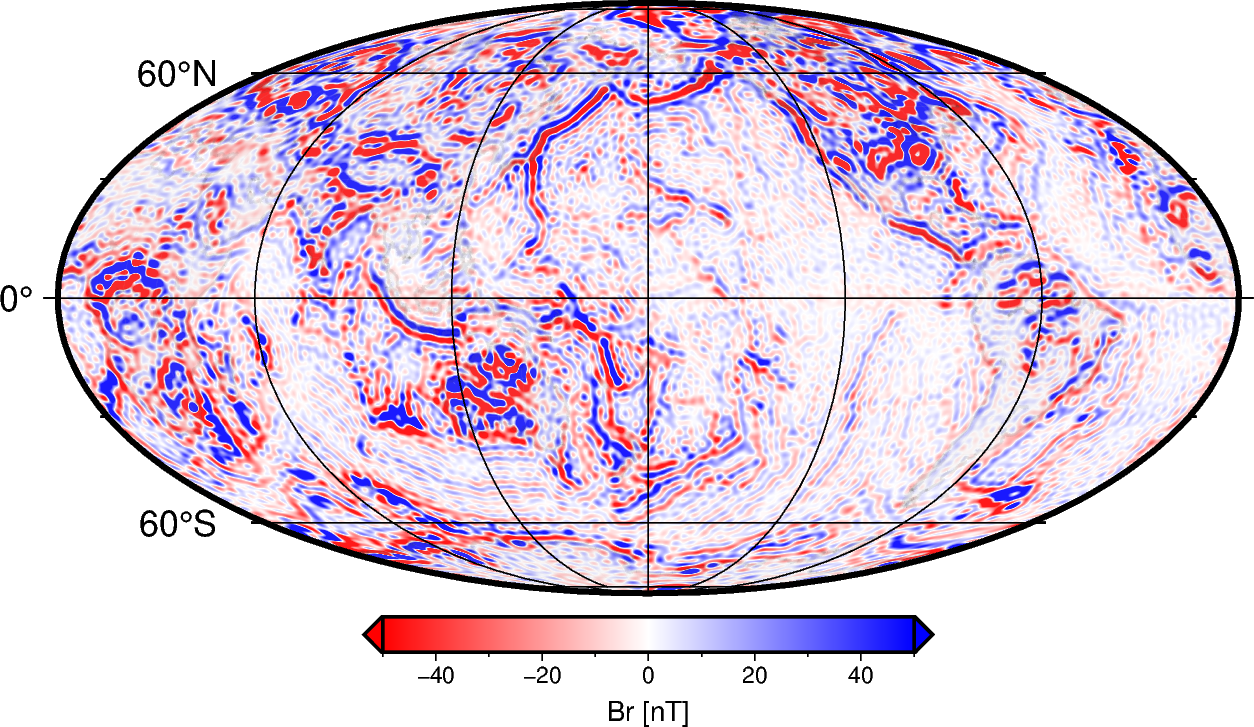

In [76]:
cmax=50
region = 'g'
projection = 'W10c'

fig=pygmt.Figure()

radi = pygmt.grdsample(grid=model_rad.to_xarray(), spacing='0.05d')
pygmt.config(COLOR_FOREGROUND='red', COLOR_BACKGROUND='blue')
pygmt.makecpt(cmap='polar', series='-{:f}/{:f}'.format(float(cmax), float(cmax)), reverse=True)
fig.grdimage(region=region, projection=projection, 
             grid=radi, transparency=10)

fig.coast(shorelines='0.5p,gray20', resolution='l', area_thresh=5000.,
          region=region, projection=projection, land='gray', transparency=90)
fig.basemap(frame=['afg','WSne'], region=region, projection=projection)

pygmt.config(COLOR_FOREGROUND='red', COLOR_BACKGROUND='blue')
pygmt.makecpt(cmap='polar', series='-{:f}/{:f}'.format(float(cmax), float(cmax)), reverse=True)
with pygmt.config(FONT_ANNOT_PRIMARY='10p', FONT_LABEL='12p'):
    fig.colorbar(position='JBC+jBC+o0.0c/-0.5c+w4.5c/0.3c+h+e', frame=['x+lBr [nT]'])#, box='+gwhite+p0.2p')
    
fig.show(width=800)